In [10]:
import pandas as pd
import numpy as np
import re
import os
import string
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [12]:
path = kagglehub.dataset_download("stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset")

# 2. LISTAR los archivos reales que están dentro de esa ruta
print("Archivos encontrados en la ruta de Kaggle:")
print(os.listdir(path))

Using Colab cache for faster access to the 'rotten-tomatoes-movies-and-critic-reviews-dataset' dataset.
Archivos encontrados en la ruta de Kaggle:
['rotten_tomatoes_movies.csv', 'rotten_tomatoes_critic_reviews.csv']


In [56]:
# Celda 3: Carga de datos
path = kagglehub.dataset_download("stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset")
# Ajusta la ruta según los archivos que encuentres en 'path'
movies_df = pd.read_csv(f"{path}/rotten_tomatoes_movies.csv")
reviews_df = pd.read_csv(f"{path}/rotten_tomatoes_critic_reviews.csv")

# Selección de campos: Para un mejor contexto, podemos combinar título y crítica.
# Crearemos un campo 'texto_completo' para indexar.
movies_df['texto_para_indexar'] = reviews_df['review_content'].fillna('') + " [Pelicula: " + movies_df['movie_title'].fillna('') + "]"
print("Corpus cargado. Total de críticas:", len(reviews_df))

Using Colab cache for faster access to the 'rotten-tomatoes-movies-and-critic-reviews-dataset' dataset.
Corpus cargado. Total de críticas: 1130017


In [58]:
# Celda 4: Función de preprocesamiento avanzado
def preprocesar_texto(text):
    """Limpia el texto: minúsculas, elimina puntuación, números y espacios."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text) # Elimina puntuación
    text = re.sub(r'\d+', '', text)     # Elimina números
    text = re.sub(r'\s+', ' ', text)    # Espacios redundantes
    return text.strip()

# Aplicamos el preprocesamiento a TODO el corpus ANTES de generar embeddings
print("Aplicando preprocesamiento...")
movies_df['texto_limpio'] = movies_df['texto_para_indexar'].apply(preprocess_text)
print("Preprocesamiento completado.")

Aplicando preprocesamiento...
Preprocesamiento completado.


In [60]:
# Celda 5: Generación de embeddings
print("Cargando el modelo de Sentence Transformers...")
modelo = SentenceTransformer('all-MiniLM-L6-v2')
print("Modelo cargado.")

# Obtenemos los textos ya preprocesados en una lista
documentos_limpios = movies_df['texto_limpio'].tolist()

# Generamos embeddings en lotes (batch_size=32 es un buen punto de partida)
print("Generando embeddings para todos los documentos...")
embeddings_documentos = modelo.encode(documentos_limpios, batch_size=32, show_progress_bar=True)
print("Embeddings generados con forma:", embeddings_documentos.shape)

Cargando el modelo de Sentence Transformers...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado.
Generando embeddings para todos los documentos...


Batches:   0%|          | 0/554 [00:00<?, ?it/s]

Embeddings generados con forma: (17712, 384)


In [61]:
# Celda 6: Función de búsqueda
def buscar(consulta, k=5):
    """
    Recibe una consulta, la preprocesa, genera su embedding y
    retorna los top-k documentos más similares.
    """
    # 1. Preprocesar la consulta
    consulta_limpia = preprocesar_texto(consulta)

    # 2. Generar el embedding de la consulta
    embedding_consulta = modelo.encode([consulta_limpia])

    # 3. Calcular la similitud del coseno contra todos los documentos
    # (Embeddings de docs ya están calculados)
    similitudes = cosine_similarity(embedding_consulta, embeddings_documentos)[0]

    # 4. Obtener los índices de los k documentos más similares
    indices_top_k = np.argsort(similitudes)[::-1][:k]

    # 5. Preparar los resultados en un DataFrame
    resultados = []
    for i, idx in enumerate(indices_top_k):
        resultados.append({
            'Ranking': i+1,
            'ID_Documento': idx,
            'Titulo_Pelicula': movies_df.loc[idx, 'movie_title'],
            'Fragmento_Texto': reviews_df.loc[idx, 'review_content'][:200] + "...", # Primeros 200 caracteres
            'Similitud': similitudes[idx]
        })
    return pd.DataFrame(resultados)

In [62]:
queries = [
    "Q1 science fiction movie with advanced technology",
    "Q2 romantic story with emotional relationships",
    "Q3 action movie with intense fight scenes",
    "Q4 horror film that creates fear and suspense",
    "Q5 visually impressive movie with weak storyline",
    "Q6 emotionally moving performance by the lead actor",
    "Q7 predictable plot but entertaining experience",
    "Q8 movie praised by critics but unpopular with audiences"
]

In [74]:
# Ejecutar una consulta
consulta_q1 = "science fiction movie with advanced technology"
resultados_q1 = buscar(consulta_q1, k=5)
resultados_q1

,Ranking,ID_Documento,Titulo_Pelicula,Fragmento_Texto,Similitud
0,1,9468,Licence To Kill,This movie does what science fiction is suppos...,0.617181
1,2,6064,Erik the Viking,"Technology is the film's only hook. Otherwise,...",0.561283
2,3,9472,Life of Pi,"Its humanity, some cool technology and Bruce W...",0.514115
3,4,3526,The Big Brass Ring,The movie seems more like a '50s science ficti...,0.508068
4,5,15674,The Quake (Skjelvet),"An intelligent, well observed movie about adul...",0.493087


In [75]:
consulta_q2 = "romantic story with emotional relationships"
resultados_q2 = buscar(consulta_q2, k=5)
resultados_q2

,Ranking,ID_Documento,Titulo_Pelicula,Fragmento_Texto,Similitud
0,1,12592,Road Hard,A sobering drama that at its core is a heteros...,0.543921
1,2,11171,North to Alaska,...the story of how two emotionally damaged bu...,0.535027
2,3,625,Next of Kin,Charly comes off as emotionally manipulative a...,0.527421
3,4,2245,A Wake In Providence (Almost Married),"A contrived, rather unpleasant English-lingo t...",0.511376
4,5,9792,Love Field,"A tender, tangy and wild tale in a kooky conve...",0.491357


In [79]:
consulta_q3 = "action movie with intense fight scenes"
resultados_q3 = buscar(consulta_q3, k=5)
resultados_q3

,Ranking,ID_Documento,Titulo_Pelicula,Fragmento_Texto,Similitud
0,1,15191,The Hunt (Jagten),Repo Men is a mess of a film but it's third ac...,0.585070
1,2,10767,Music Within,"Unfortunately, the martial arts action is only...",0.581060
2,3,1465,Are We There Yet?,The repetition of the action scenes play like ...,0.568429
3,4,12306,RBG,"A stodgy but good-looking war film, with many ...",0.559401
4,5,10780,My Amityville Horror,"Takes its time to get going, but once the acti...",0.549241


In [80]:
consulta_q4 = "visually impressive movie with weak storyline"
resultados_q4 = buscar(consulta_q4, k=5)
resultados_q4

,Ranking,ID_Documento,Titulo_Pelicula,Fragmento_Texto,Similitud
0,1,5283,Deadpool 2,A weak plot still makes a viable vehicle for a...,0.622106
1,2,5995,Empties (Vratné lahve),"Disappointing, badly plotted thriller, let dow...",0.605440
2,3,12014,The President's Analyst,"Disappointing, sluggishly directed medieval th...",0.604453
3,4,10753,Murder to Mercy: The Cyntoia Brown Story,"Created under the vague guise of ""inspirationa...",0.599936
4,5,15214,The Inbetweeners,"The direction is especially impressive, but th...",0.596534


In [82]:
consulta_q5 = "visually impressive movie with weak storyline"
resultados_q5 = buscar(consulta_q5, k=5)
resultados_q5

,Ranking,ID_Documento,Titulo_Pelicula,Fragmento_Texto,Similitud
0,1,5283,Deadpool 2,A weak plot still makes a viable vehicle for a...,0.622106
1,2,5995,Empties (Vratné lahve),"Disappointing, badly plotted thriller, let dow...",0.605440
2,3,12014,The President's Analyst,"Disappointing, sluggishly directed medieval th...",0.604453
3,4,10753,Murder to Mercy: The Cyntoia Brown Story,"Created under the vague guise of ""inspirationa...",0.599936
4,5,15214,The Inbetweeners,"The direction is especially impressive, but th...",0.596534


In [83]:
consulta_q6 = "emotionally moving performance by the lead actor"
resultados_q6 = buscar(consulta_q6, k=5)
resultados_q6

,Ranking,ID_Documento,Titulo_Pelicula,Fragmento_Texto,Similitud
0,1,3360,Before I Fall,"The dialogue cuts like a knife, and the two le...",0.513505
1,2,10375,Midnight Special,Much of the domestic emotion feels contrived. ...,0.502703
2,3,6122,Evergreen,"Very unpleasant, though skilfully put together...",0.491218
3,4,287,La MISSION,The most underrated American director this sid...,0.483830
4,5,10363,Middle of Nowhere,I found something questionable in its forced a...,0.482883


In [84]:
consulta_q7 = "predictable plot but entertaining experience"
resultados_q7 = buscar(consulta_q7, k=5)
resultados_q7

,Ranking,ID_Documento,Titulo_Pelicula,Fragmento_Texto,Similitud
0,1,11336,On the Road,"Predictable and been-there, seen-that, but ent...",0.607987
1,2,9286,Last Weekend,"Predictable as the premise is, Travolta's and ...",0.595448
2,3,12684,Romeo and Juliet,"Sometimes predictable, but it takes a number o...",0.580341
3,4,9447,Letters To God,Has an initially intriguing premise and plenty...,0.576281
4,5,281,Winter's Bone,"Doesn't have much plot, just characters intera...",0.564369


In [85]:
consulta_q8 = "movie praised by critics but unpopular with audiences"
resultados_q8 = buscar(consulta_q8, k=5)
resultados_q8

,Ranking,ID_Documento,Titulo_Pelicula,Fragmento_Texto,Similitud
0,1,12159,Pusher III: I'm the Angel of Death,Every once in a while a movie comes around tha...,0.625319
1,2,1058,Persuasion,Movies like this are beyond criticism....,0.601613
2,3,9500,Life Partners,"I predict that when this film is released, lot...",0.590458
3,4,11195,Not Without My Daughter,It fails to either engage or appeal in a big w...,0.572127
4,5,12753,Run with the Hunted,Despite some entertaining moments and a terrif...,0.567347


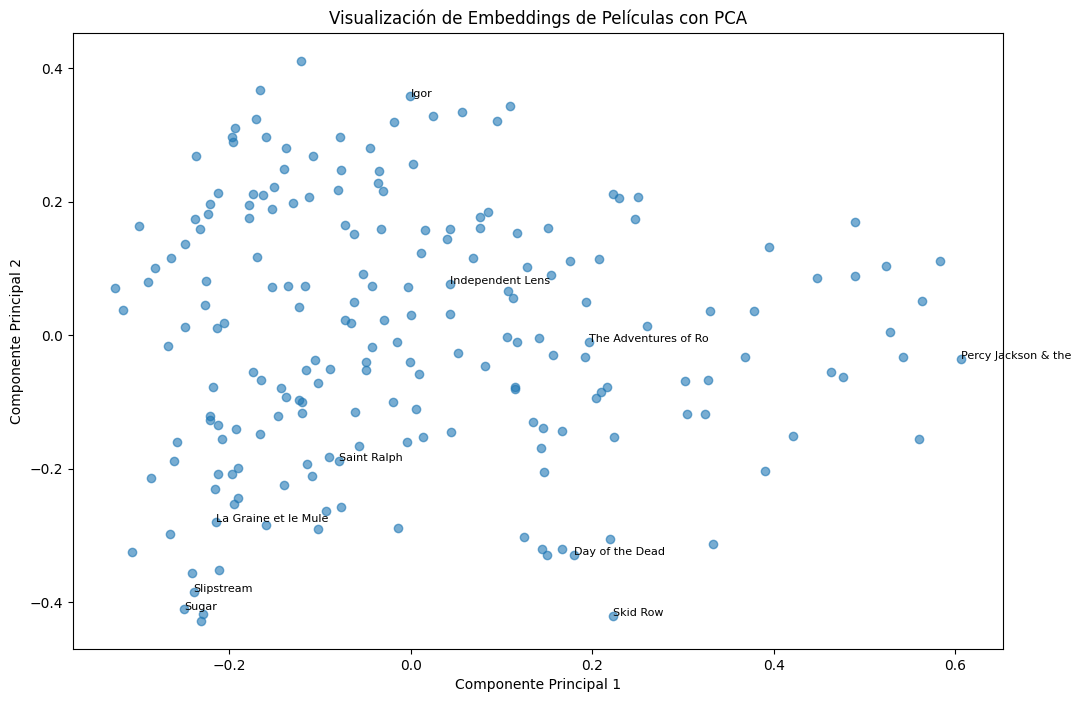

In [87]:
# Celda de Excelencia: Visualización con PCA
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Tomamos los embeddings de los primeros 200 documentos para no saturar el gráfico
muestra_embeddings = embeddings_documentos[:200]
muestra_titulos = movies_df['movie_title'].head(200).tolist()

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(muestra_embeddings)

plt.figure(figsize=(12, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6)
# Anotamos algunos puntos para dar contexto
for i, titulo in enumerate(muestra_titulos):
    if i % 20 == 0: # Anotamos cada 20 títulos para no saturar
        plt.annotate(titulo[:20], (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=8)
plt.title('Visualización de Embeddings de Películas con PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

In [88]:
resumen_final = []
for i, q in enumerate(queries, 1):
    res = buscar(q, k=1).iloc[0] # Obtenemos el top-1 de cada consulta
    resumen_final.append({
        'Consulta': f'Q{i}',
        'Documento Top-1 ID': res['ID_Documento'],
        'Título Película': res['Titulo_Pelicula'],
        'Similitud': round(res['Similitud'], 4)
    })
pd.DataFrame(resumen_final)

,Consulta,Documento Top-1 ID,Título Película,Similitud
0,Q1,9468,Licence To Kill,0.5729
1,Q2,12592,Road Hard,0.5667
2,Q3,15191,The Hunt (Jagten),0.5723
3,Q4,6138,Everybody Knows... Elizabeth Murray,0.6218
4,Q5,11782,Phantasm: Ravager,0.5637
5,Q6,3360,Before I Fall,0.4932
6,Q7,12014,The President's Analyst,0.5274
7,Q8,12159,Pusher III: I'm the Angel of Death,0.5326
